## Cálculo de CER

Cálculo del Character Error Rate por categorías de keywords usando alineación (jiwer) y distancia de Levenshtein.

In [1]:
from tools.cer_utils import load_dataset, calculate_cer_from_dataframe

df = load_dataset('dataset_normalized.csv')
cer_df = calculate_cer_from_dataframe(df, 'keywords.json')


In [2]:
from tools.cer_analysis import CERAnalyzer, CERVisualizer
analyzer = CERAnalyzer(cer_df)
grouped = analyzer.get_grouped_by_provider_snr_category()
grouped.head(3)

,provider,snr,category,edit_distance,ref_length,cer,cer_pct
0,amazon,0dB,Nombres Propios,955,4710,0.202760,20.276008
1,amazon,0dB,Números/Cod.Alfa,228,1530,0.149020,14.901961
2,amazon,0dB,Vocabulario de Negocio,725,10980,0.066029,6.602914


Rendimiento Global del Sistema (CER Promedio con IC 95%)


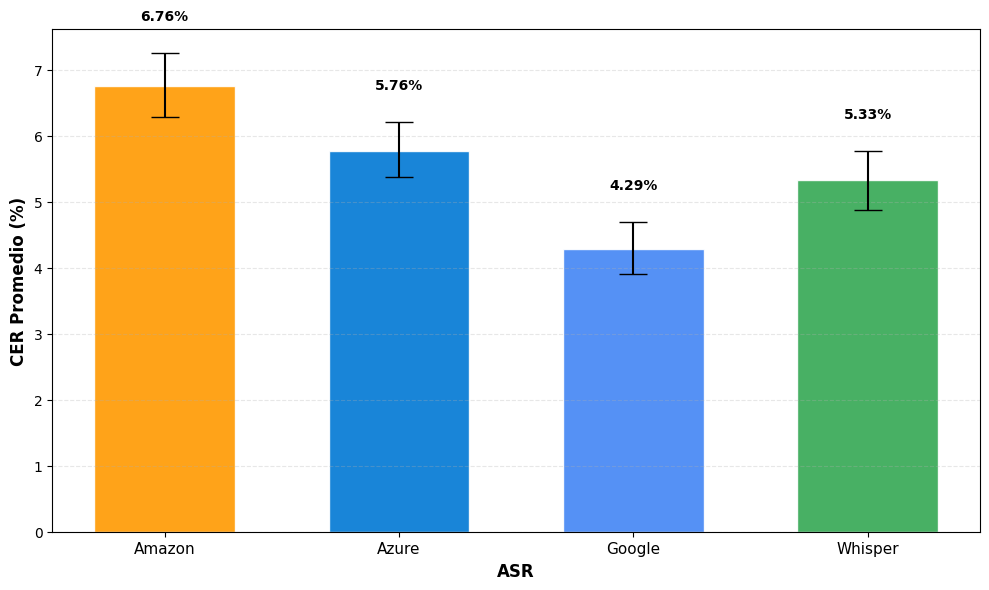

Tabla Comparativa: Rendimiento Global con Intervalos de Confianza


ASR,CER Global,Errores,Caracteres,IC 95% Inf,IC 95% Sup
amazon,6.76%,3881,57400,6.29%,7.25%
azure,5.76%,3309,57400,5.37%,6.21%
google,4.29%,2461,57400,3.91%,4.69%
whisper,5.33%,3057,57400,4.88%,5.76%



Análisis Estadístico de Significancia (CER Global)
N (muestras/bloques) = 9300
Test de Friedman: Estadístico=217.7312, p-value=6.2109e-47, W de Kendall=0.0078
>> Diferencias significativas encontradas. Realizando post-hoc (Wilcoxon + Holm-Bonferroni)...


Comparación,Estadístico W,p-value original,p-value adj (Holm-Bonferroni),Significativo,Tamaño del Efecto (r)
amazon vs azure,518952,2.6426e-10,7.9277e-10,True,0.8453
amazon vs google,273394,4.0234e-38,2.4140e-37,True,0.8551
amazon vs whisper,397902,3.8374e-22,1.9187e-21,True,0.8501
azure vs google,336016,2.0400e-14,8.1599e-14,True,0.8526
azure vs whisper,437691,9.4180e-05,1.8836e-04,True,0.8485
google vs whisper,308384,1.0320e-03,1.0320e-03,True,0.8537


In [3]:
# Cálculo de CER global por proveedor (agregando todas las categorías)
global_cer_stats = analyzer.get_global_cer_by_provider_with_ci()

# Test de Friedman + post-hoc (Wilcoxon + Holm-Bonferroni) para CER global
friedman_global, wilcoxon_global = analyzer.perform_statistical_tests(category=None)

# Gráfico de Barras Global
CERVisualizer.plot_global_cer(global_cer_stats, title="Rendimiento Global del Sistema (CER Promedio con IC 95%)")

# Tabla de estadísticas globales (formato similar a WER)
display(CERVisualizer.display_global_cer_table(global_cer_stats))

# Resultados estadísticos: Friedman y post-hoc
CERVisualizer.display_global_statistical_results(friedman_global, wilcoxon_global)

In [4]:
global_grouped = analyzer.get_global_by_category()
CERVisualizer.display_global_by_category(global_grouped, title="Global CER by Category")

cer_by_snr = analyzer.get_cer_by_snr_and_category()
CERVisualizer.display_cer_by_snr(cer_by_snr, title="Variación del CER por nivel de ruido")



category,edit_distance,ref_length,cer,cer_pct
Nombres Propios,6631,62800,0.105589,10.558917
Números/Cod.Alfa,1401,20400,0.068676,6.867647
Vocabulario de Negocio,4676,146400,0.031940,3.193989


snr,category,cer clean,cer 10db,cer 5db,cer 0db
,Nombres Propios,4.076433,6.003185,8.328025,19.506369
,Números/Cod.Alfa,4.019608,3.284314,4.297386,13.970588
,Vocabulario de Negocio,0.990437,1.042805,1.960383,7.313297


Evolución del CER por Nivel de Ruido y Categoría


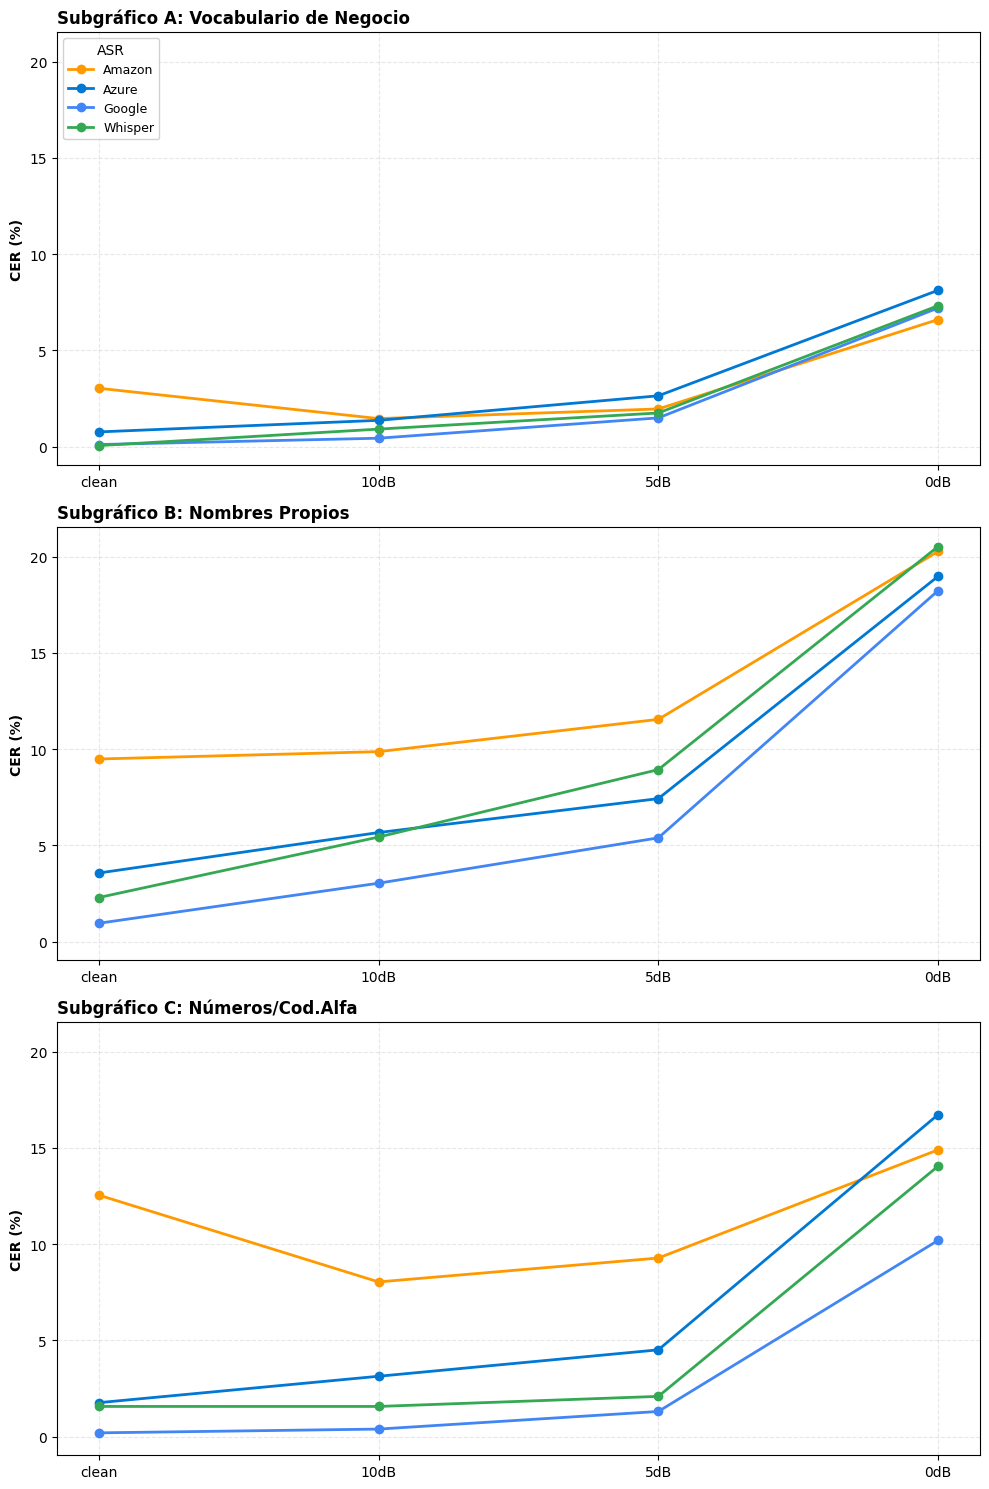

In [5]:
# Panel de evolución del CER por SNR para las 3 categorías principales
CERVisualizer.plot_cer_by_snr_and_category_panel(cer_df, title="Evolución del CER por Nivel de Ruido y Categoría")

# Tabla detallada: Degradación del CER por categoría y nivel de ruido
detailed_cer_stats = analyzer.get_cer_by_provider_snr_category_with_ci()
CERVisualizer.display_detailed_cer_table(detailed_cer_stats)